## Average Filtering using OpenCV

This program applies an **Average Filter** to a grayscale image using OpenCV.

- `cv2.imread()` reads the image in grayscale.
- NumPy creates **3×3, 5×5, and 7×7** average kernels.
- `cv2.filter2D()` applies 2D convolution using each kernel.
- `matplotlib` displays the original and filtered images.
- A larger kernel size produces more smoothing and blur.

**Result:** The 3×3 filter gives less blur, while the 7×7 filter gives stronger smoothing.

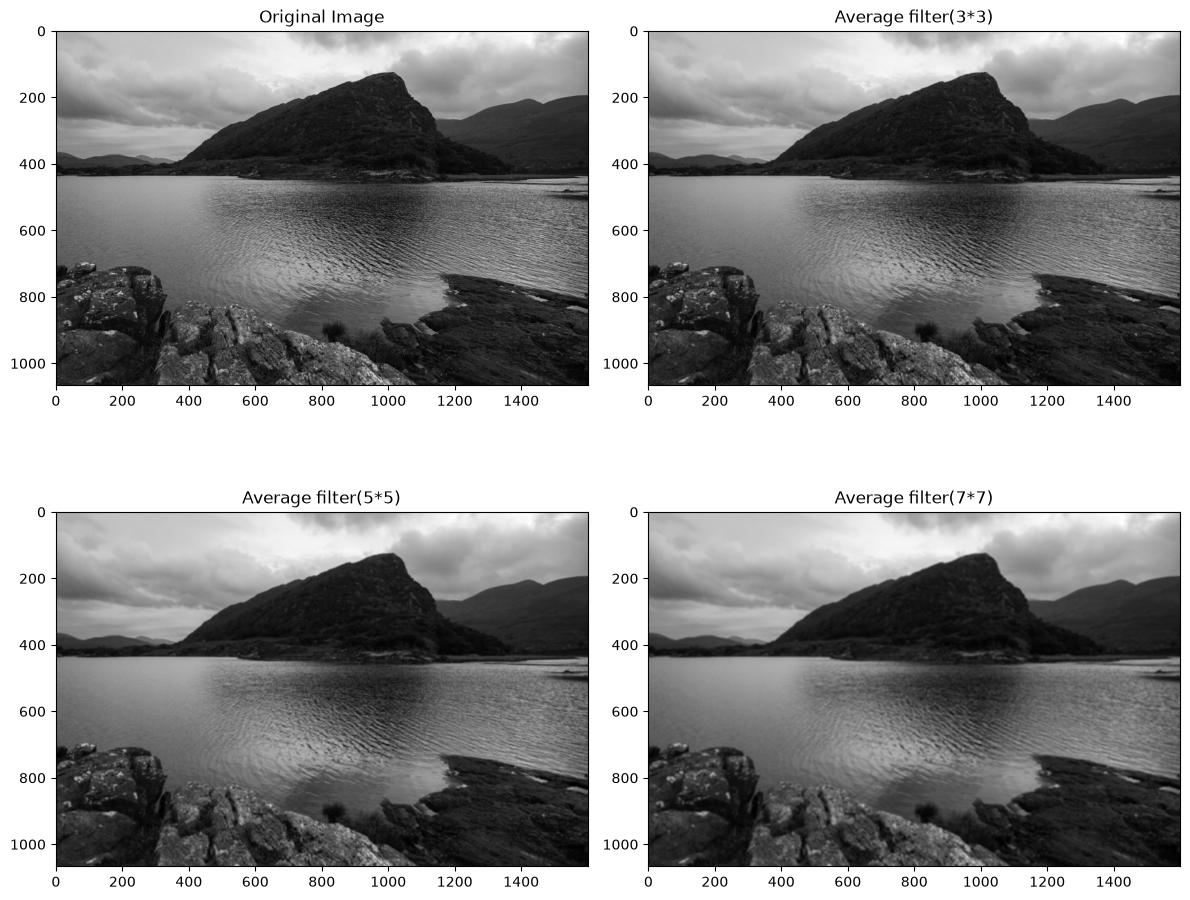

In [7]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
#function to display images
def show_comparison(original,blur3,blur5,blur7):
  plt.figure(figsize=(12,10))

  #original image
  plt.subplot(2,2,1)
  plt.imshow(original,cmap='gray')
  plt.title('Original Image')
  plt.axis('on')

  #3*3 kernal
  plt.subplot(2,2,2)
  plt.imshow(blur3,cmap='gray')
  plt.title("Average filter(3*3)")
  plt.axis('on')

  #5*5 kernal
  plt.subplot(2,2,3)
  plt.imshow(blur5,cmap='gray')
  plt.title("Average filter(5*5)")
  plt.axis('on')
  #7*7 kernel
  plt.subplot(2,2,4)
  plt.imshow(blur7,cmap='gray')
  plt.title("Average filter(7*7)")
  plt.axis('on')
  plt.tight_layout()
  plt.show()

  #read image in grayscale
img = cv2.imread('image.jpg',0)
if img is None:
  print('Error: Could not read image')
else:
  kernel_3_3=np.ones((3,3),np.float32)/9
  kernel_5_5=np.ones((5,5),np.float32)/25
  kernel_7_7=np.ones((7,7),np.float32)/49

  #apply each kernel to the image using 2d convolution
  blur_3_3=cv2.filter2D(img,-1,kernel_3_3)
  blur_5_5=cv2.filter2D(img,-1,kernel_5_5)
  blur_7_7=cv2.filter2D(img,-1,kernel_7_7)

  #display the original and blurred images for comparision
  show_comparison(img,blur_3_3,blur_5_5,blur_7_7)

## Average Filtering Without OpenCV

This program applies an **Average Filter from scratch** without using `cv2`.

- NumPy is used for image and kernel calculations.
- The image is read using `plt.imread()` and converted to grayscale.
- **3×3, 5×5, and 7×7** average kernels are created.
- Padding is added to handle boundary pixels.
- `for` loops manually apply the filter to each pixel.
- The neighboring pixel values are averaged to produce the output.
- Finally, the original and filtered images are displayed for comparison.

**Result:** Larger kernel sizes produce stronger smoothing and blur.

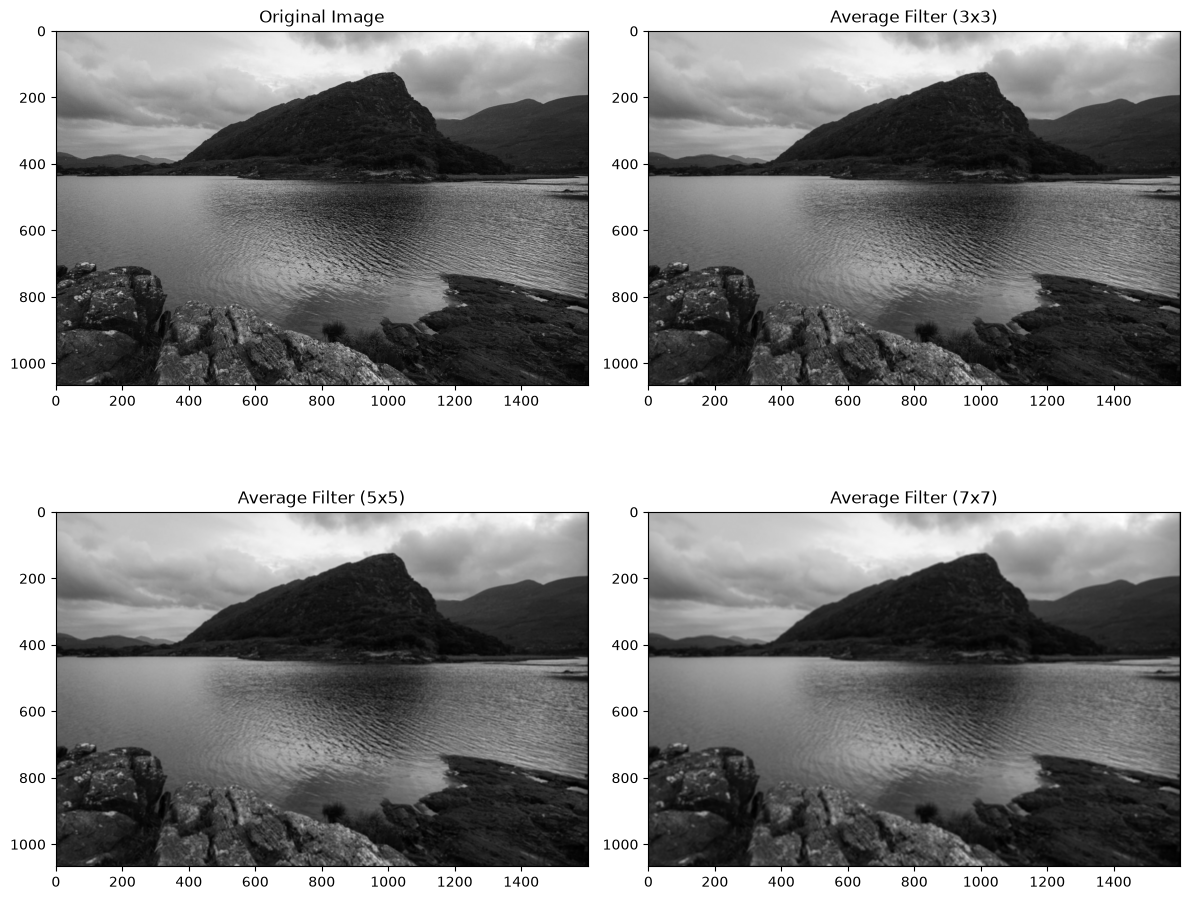

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# Function to apply average filter from scratch
def average_filter(image, kernel_size):
    pad = kernel_size // 2

    # Add zero padding around the image
    padded = np.pad(image, pad, mode='constant', constant_values=0)

    # Create output image
    output = np.zeros_like(image, dtype=np.float32)

    # Average filter kernel
    kernel = np.ones((kernel_size, kernel_size), dtype=np.float32)
    kernel = kernel / (kernel_size * kernel_size)

    # Apply filter
    for i in range(image.shape[0]):
        for j in range(image.shape[1]):

            # Get the region around the pixel
            region = padded[i:i + kernel_size,
                            j:j + kernel_size]

            # Multiply region with kernel and calculate sum
            output[i, j] = np.sum(region * kernel)

    return output.astype(np.uint8)


# Function to display images
def show_comparison(original, blur3, blur5, blur7):

    plt.figure(figsize=(12, 10))

    # Original image
    plt.subplot(2, 2, 1)
    plt.imshow(original, cmap='gray')
    plt.title('Original Image')
    plt.axis('on')

    # 3x3 kernel
    plt.subplot(2, 2, 2)
    plt.imshow(blur3, cmap='gray')
    plt.title('Average Filter (3x3)')
    plt.axis('on')

    # 5x5 kernel
    plt.subplot(2, 2, 3)
    plt.imshow(blur5, cmap='gray')
    plt.title('Average Filter (5x5)')
    plt.axis('on')

    # 7x7 kernel
    plt.subplot(2, 2, 4)
    plt.imshow(blur7, cmap='gray')
    plt.title('Average Filter (7x7)')
    plt.axis('on')

    plt.tight_layout()
    plt.show()


# Read image WITHOUT cv2
img = plt.imread('image.jpg')

# Convert RGB image to grayscale
if len(img.shape) == 3:
    img = np.mean(img[:, :, :3], axis=2)

# Apply average filters
blur_3_3 = average_filter(img, 3)
blur_5_5 = average_filter(img, 5)
blur_7_7 = average_filter(img, 7)

# Display results
show_comparison(img, blur_3_3, blur_5_5, blur_7_7)